# **Dataset USAccDeath**

O conjunto de dados **USAccDeaths** é um clássico no estudo de séries temporais, amplamente utilizado para demonstrar a análise de sazonalidade anual e tendência, com um componente sazonal particularmente forte e bem definido.

## **Visão Geral do Dataset USAccDeaths**

* **Conteúdo:** Número mensal de mortes acidentais nos Estados Unidos (incluindo acidentes de trânsito, domésticos, etc.) .
* **Período:**	De janeiro de 1973 a dezembro de 1978 (72 observações) .
Frequência	Mensal (12 observações por ano).

* **Número de Observações:**	72 meses (6 anos completos).

* **Propósito:**	Um exemplo clássico para demonstrar séries com sazonalidade anual muito clara e tendência de queda.

##  Características e Aplicações

O USAccDeaths é um dataset ótimo por apresentar uma sazonalidade forte e bem definida, que permite explorar conceitos fundamentais de séries temporais:

1. **Sazonalidade Anual com Padrão de "Picos" no Verão**
O grande destaque deste dataset é o padrão sazonal claro: o número de mortes acidentais aumenta significativamente no verão (especialmente em julho) e diminui no inverno . Isso reflete o aumento da atividade humana, viagens e exposição a riscos durante os meses mais quentes


2. Tendência de Queda
Ao longo dos 6 anos, observa-se uma tendência geral de queda no número de mortes, refletindo provavelmente melhorias na segurança veicular, campanhas de conscientização e avanços na medicina de emergência.


3. Padrão Sazonal com "Pico" em Julho
O padrão sazonal é muito nítido

4. Ciclo Anual Muito Regular
A série apresenta uma periodicidade anual extremamente regular, o que facilita a identificação visual e a modelagem. É um excelente dataset para demonstrar que a sazonalidade pode ser modelada com defasagens de 12 no modelo SARIMA

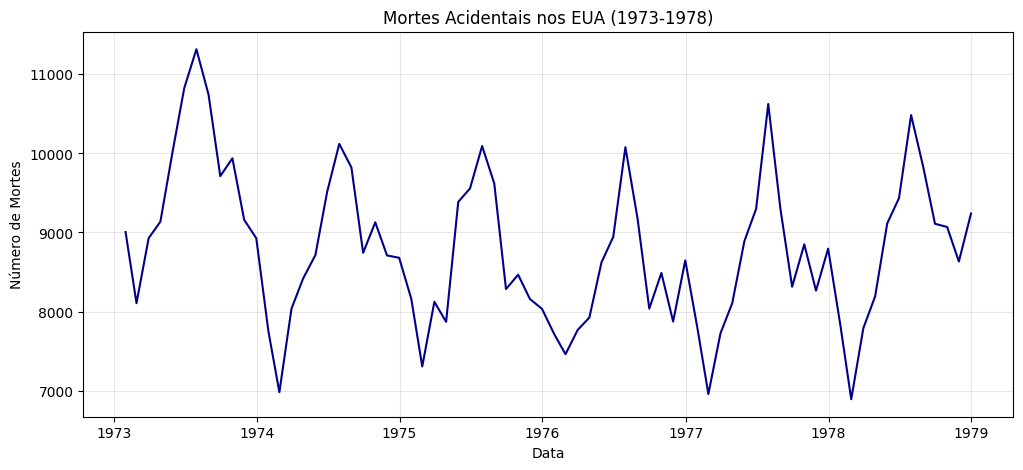

In [45]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Carregar o dataset
us_data = sm.datasets.get_rdataset('USAccDeaths')
df = us_data.data

# Converter para série temporal (formato mensal)
import pandas as pd
df['date'] = pd.date_range(start='1973-01-01', periods=len(df), freq='ME')
df.set_index('date', inplace=True)

# Plotar a série
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['value'], linewidth=1.5, color='darkblue')
plt.xlabel('Data')
plt.ylabel('Número de Mortes')
plt.title('Mortes Acidentais nos EUA (1973-1978)')
plt.grid(alpha=0.3)
plt.show()

In [46]:
df

,time,value
date,,
1973-01-31,1973.000000,9007
1973-02-28,1973.083333,8106
1973-03-31,1973.166667,8928
1973-04-30,1973.250000,9137
1973-05-31,1973.333333,10017
...,...,...
1978-08-31,1978.583333,9827
1978-09-30,1978.666667,9110
1978-10-31,1978.750000,9070


## **Implemente uma rede neural MLP com Sliding Sindow**

 Utilize 80% dos dados para treinamento e 20% dos dados para teste

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [48]:
len(df)

72

In [49]:
72-58

14

In [50]:
nn_base_treinamento = 58
base_treinamento =df.iloc[0:nn_base_treinamento,1].values

In [51]:
base_treinamento

array([ 9007,  8106,  8928,  9137, 10017, 10826, 11317, 10744,  9713,
        9938,  9161,  8927,  7750,  6981,  8038,  8422,  8714,  9512,
       10120,  9823,  8743,  9129,  8710,  8680,  8162,  7306,  8124,
        7870,  9387,  9556, 10093,  9620,  8285,  8466,  8160,  8034,
        7717,  7461,  7767,  7925,  8623,  8945, 10078,  9179,  8037,
        8488,  7874,  8647,  7792,  6957,  7726,  8106,  8890,  9299,
       10625,  9302,  8314,  8850])

In [52]:
base_treinamento.shape

(58,)

In [53]:
base_treinamento =base_treinamento.reshape(-1,1)

In [54]:
base_treinamento.shape

(58, 1)

In [55]:
from sklearn.preprocessing import MinMaxScaler
normalizador =MinMaxScaler(feature_range=(0,1))
normalizador_previsores = MinMaxScaler(feature_range=(0,1))

In [56]:
base_treinamento_normalizada =normalizador.fit_transform(base_treinamento)

In [57]:
intervalo_previsao =4

In [58]:
X_treinamento=[] #previsores
y_treinamento =[] #preço real

for i in range(intervalo_previsao,nn_base_treinamento):
    X_treinamento.append(base_treinamento_normalizada[i-intervalo_previsao:i,0])
    y_treinamento.append(base_treinamento_normalizada[i,0])

In [59]:
#Convertendo X e y de Listas para Arrays
X_treinamento = np.array(X_treinamento)
y_treinamento =np.array(y_treinamento)

In [60]:
base_teste = df.iloc[nn_base_treinamento:,1].values

In [61]:
base_teste

array([ 8265,  8796,  7836,  6892,  7791,  8192,  9115,  9434, 10484,
        9827,  9110,  9070,  8633,  9240])

In [62]:
y_teste = base_teste.copy()

In [63]:
base_teste =base_teste.reshape(-1,1)

In [64]:
base_completa = df['value']

In [65]:
entradas = base_completa[len(base_completa) - len(base_teste) - intervalo_previsao:].values

In [66]:
entradas = entradas.reshape(-1, 1)
entradas.shape

(18, 1)

In [67]:
entradas_normalizadas = normalizador.transform(entradas)

In [68]:
entradas_normalizadas

array([[ 0.8412844 ],
       [ 0.53784404],
       [ 0.31123853],
       [ 0.43417431],
       [ 0.3       ],
       [ 0.42178899],
       [ 0.2016055 ],
       [-0.01490826],
       [ 0.1912844 ],
       [ 0.28325688],
       [ 0.49495413],
       [ 0.56811927],
       [ 0.80894495],
       [ 0.65825688],
       [ 0.49380734],
       [ 0.48463303],
       [ 0.38440367],
       [ 0.52362385]])

In [69]:
X_teste = []
nn_entradas =len(entradas)
for i in range(intervalo_previsao, nn_entradas):
  #print(i)
  X_teste.append(entradas_normalizadas[i - intervalo_previsao:i, 0])

In [70]:
X_teste_array =np.array(X_teste)

In [71]:
X_teste_array = np.reshape(X_teste_array,( X_teste_array.shape[0],X_teste_array.shape[1]))

In [72]:
X_teste_array.shape

(14, 4)

In [73]:
y_teste

array([ 8265,  8796,  7836,  6892,  7791,  8192,  9115,  9434, 10484,
        9827,  9110,  9070,  8633,  9240])

In [74]:
from sklearn.neural_network import MLPRegressor

In [75]:
# Criar o modelo MLP
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(80, 50,30),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

In [76]:
history = mlp_regressor.fit(X_treinamento, y_treinamento)

Iteration 1, loss = 0.02730561
Validation score: 0.126941
Iteration 2, loss = 0.02390445
Validation score: 0.142781
Iteration 3, loss = 0.02202387
Validation score: 0.139211
Iteration 4, loss = 0.02110111
Validation score: 0.141428
Iteration 5, loss = 0.02055813
Validation score: 0.160213
Iteration 6, loss = 0.01995282
Validation score: 0.192977
Iteration 7, loss = 0.01916735
Validation score: 0.234662
Iteration 8, loss = 0.01824829
Validation score: 0.279846
Iteration 9, loss = 0.01733370
Validation score: 0.323188
Iteration 10, loss = 0.01657254
Validation score: 0.356399
Iteration 11, loss = 0.01604142
Validation score: 0.381057
Iteration 12, loss = 0.01563395
Validation score: 0.401892
Iteration 13, loss = 0.01521108
Validation score: 0.419576
Iteration 14, loss = 0.01472423
Validation score: 0.434607
Iteration 15, loss = 0.01415570
Validation score: 0.447549
Iteration 16, loss = 0.01358981
Validation score: 0.457624
Iteration 17, loss = 0.01308315
Validation score: 0.464051
Iterat

In [77]:
previsoes_normalizadas = mlp_regressor.predict(X_teste_array)

In [78]:
previsoes_normalizadas = previsoes_normalizadas.reshape(-1, 1)

In [79]:
previsores_reais =normalizador.inverse_transform(previsoes_normalizadas )

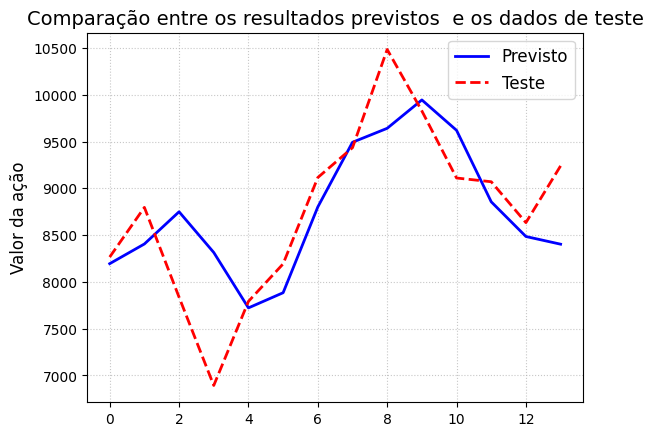

In [80]:
# Plotando as duas curvas

plt.plot( previsores_reais, 'b-', linewidth=2, label='Previsto')      # Curva azul
plt.plot( y_teste, 'r--', linewidth=2, label='Teste')  # Curva vermelha tracejada

# Personalizando o gráfico
plt.title('Comparação entre os resultados previstos  e os dados de teste', fontsize=14)
plt.ylabel('Valor da ação', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)  # Grade pontilhada
plt.legend(fontsize=12, loc='best')  # Legenda
